<a href="https://colab.research.google.com/github/Bet-Zawl/TP_project/blob/main/TP3_Data_Cleansing_TP3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP3 - Détection et Traitement des Outliers

**Difficulté:** Intermédiaire  
**Dataset:** sales_outliers.csv  
**Description:** Identification des valeurs aberrantes avec méthodes statistiques

---


## Imports des Bibliothèques


In [67]:
# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Ignorer les warnings
import warnings
warnings.filterwarnings('ignore')

# Affichage pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print(" Bibliothèques importées avec succès!")

 Bibliothèques importées avec succès!


## Import du Dataset


In [38]:
# Charger le dataset

from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/data_cleaning_project/sales_outliers.csv'
df = pd.read_csv(file_path)

#df = pd.read_csv('sales_outliers.csv')

# Afficher les informations de base
print(f"📏 Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f" Taille mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "="*80 + "\n")

# Aperçu des données
display(df.head())
print("\n" + "="*80 + "\n")

# Informations sur les colonnes
df.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📏 Dimensions: 1020 lignes × 4 colonnes
 Taille mémoire: 0.12 MB




,transaction_id,amount,product,date
0,1,1458.56,B,2023-01-01
1,2,4399.43,B,2023-01-02
2,3,1298.67,C,2023-01-03
3,4,1580.76,A,2023-01-04
4,5,946.03,C,2023-01-05




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  1020 non-null   int64  
 1   amount          1020 non-null   float64
 2   product         1020 non-null   object 
 3   date            1020 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 32.0+ KB


## Visualisation des Valeurs Manquantes


<Figure size 1400x800 with 0 Axes>

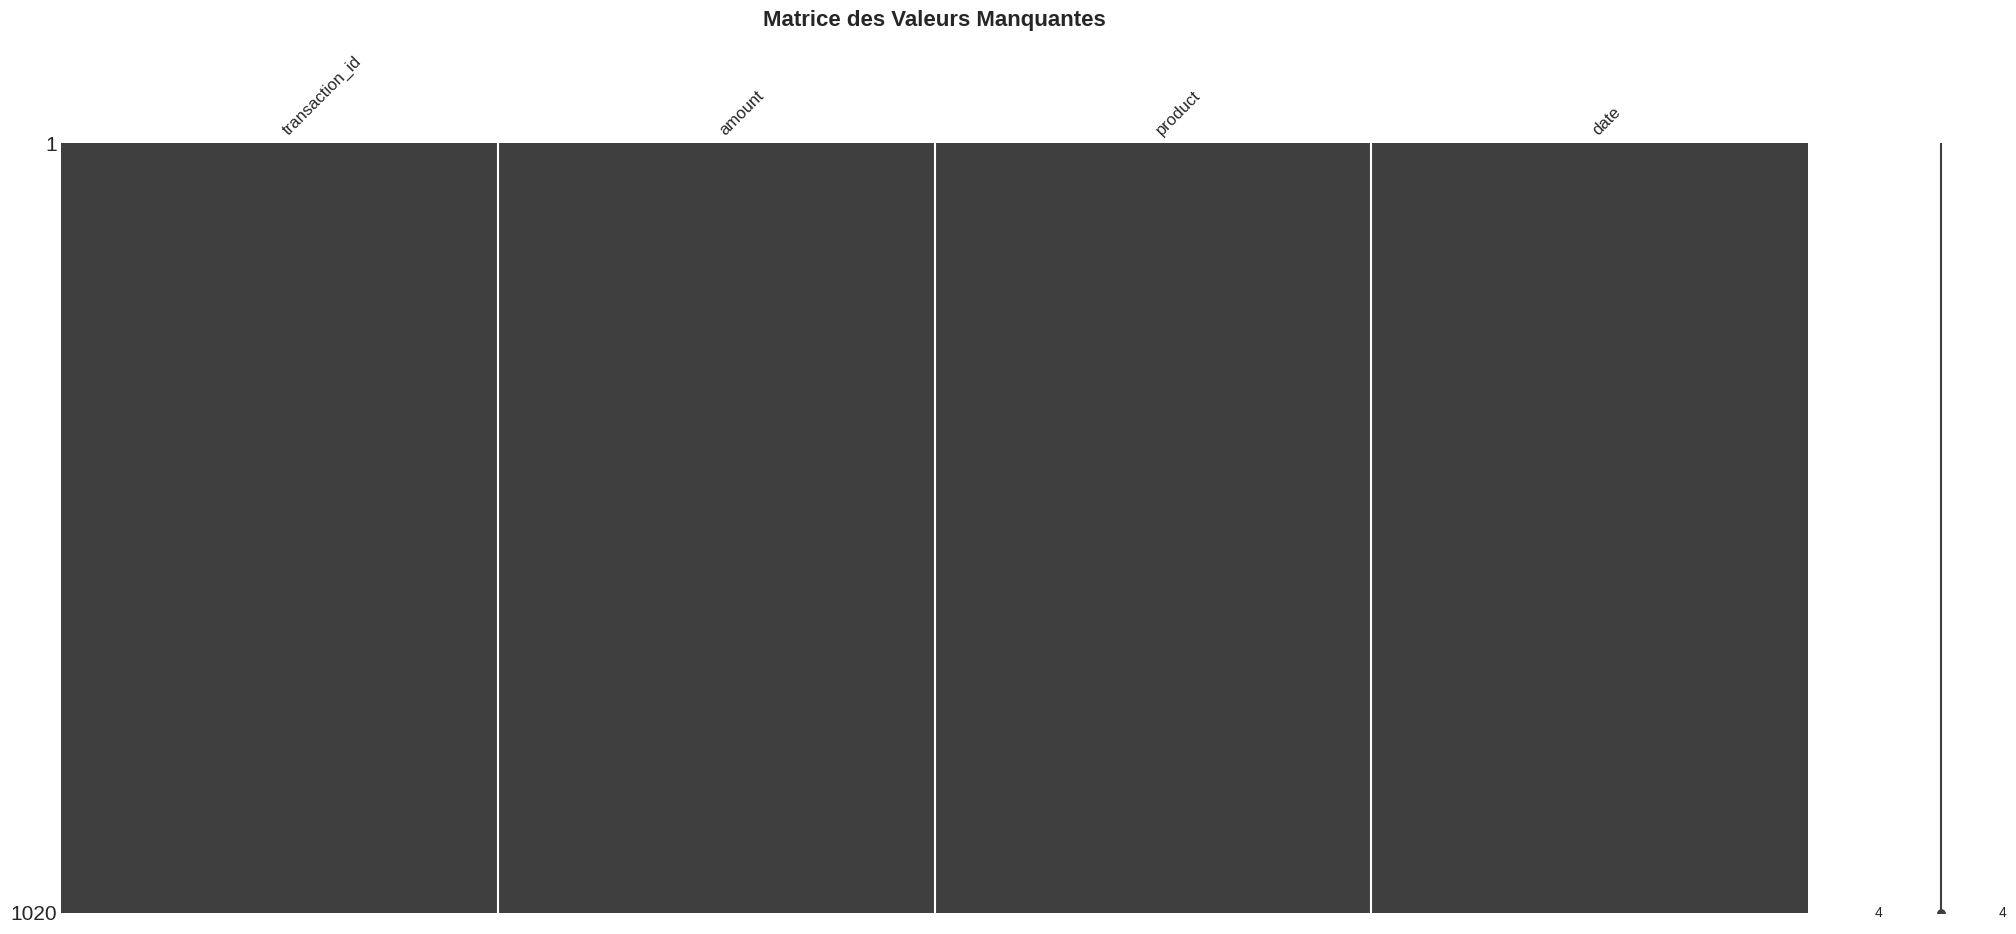


📊 Statistiques des Valeurs Manquantes:



,Nombre_Missing,Pourcentage_Missing


In [39]:
# Matrice de visualisation des valeurs manquantes
plt.figure(figsize=(14, 8))
msno.matrix(df, fontsize=12, sparkline=True)
plt.title("Matrice des Valeurs Manquantes", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Statistiques des valeurs manquantes
missing_stats = pd.DataFrame({
    'Nombre_Missing': df.isnull().sum(),
    'Pourcentage_Missing': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Pourcentage_Missing', ascending=False)

print("\n📊 Statistiques des Valeurs Manquantes:\n")
display(missing_stats[missing_stats['Nombre_Missing'] > 0])


## Questions Préalables

**Avant de commencer le TP, répondez aux questions suivantes en analysant le dataset:**

1. Quelle est la distribution de la colonne 'amount' ?
2. Y a-t-il des valeurs négatives dans les montants ?
3. Quel est le montant maximum et semble-t-il aberrant ?
4. Combien d'outliers détecte la méthode IQR pour 'amount' ?
5. Combien d'outliers détecte la méthode Z-score (threshold=3) ?
6. Les deux méthodes identifient-elles les mêmes outliers ?
7. Quelle proportion du dataset représentent les outliers ?
8. Y a-t-il une corrélation entre outliers et une catégorie spécifique ?
9. Les outliers sont-ils des erreurs ou des valeurs légitimes ?
10. Comment la moyenne change-t-elle après traitement des outliers ?


1. Distribution de la colonne 'amount'La distribution est: (array([987.,  13.,   6.,   6.,   8.]), array([7.95700000e+01, 3.72462680e+04, 7.44129660e+04, 1.11579664e+05,
       1.48746362e+05, 1.85913060e+05]), <BarContainer object of 5 artists>)
2. Valeur negatifs dans le colonne 'amount': Empty DataFrame
Columns: [transaction_id, amount, product, date]
Index: []
3. Montant maximum:     transaction_id    amount product        date
69              70 185913.06       A  2023-03-11
4. IQR Outliers detecté:
Nombre d'outliers: 105
Limites: [-7229.09, 15891.68]
5. Z-score Outliers detecté: 22
6. No. IQR = 105 outliers et z-score = 22
7. proportion d'outliers à dataset: 10.29
8. Corrélation entre outliers et catégorie spécifique:
 Il y deux possibilités: One - Association statistiquement significative entre outliers et catégorie ou Deux - Pas d'association significative détectée
9. ça depende. Les outliers sont considérés comme des valeurs légitimes, mais ça dépend aussi de la nature des don

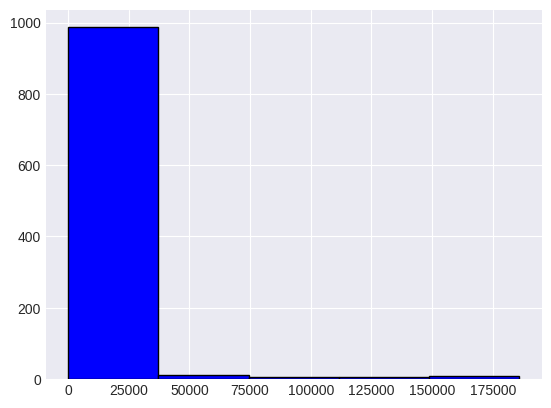

In [63]:
import matplotlib.pyplot as plt

# Cellule pour vos réponses et analyses
# Utilisez cette cellule pour explorer les données et répondre aux questions
print(f"1. Distribution de la colonne 'amount'La distribution est: {plt.hist(df['amount'], bins=5, color='blue', edgecolor='black')}")

print(f"2. Valeur negatifs dans le colonne 'amount': {df[df['amount']<0]}")
print(f"3. Montant maximum: {df[df['amount']==df['amount'].max()]}")
print(f"4. IQR Outliers detecté:")

def detect_outliers_iqr(df, column):
  Q1 = df['amount'].quantile(0.25)
  Q3 = df['amount'].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = df[(df['amount'] < lower_bound) | (df['amount'] > upper_bound)]
  return outliers, lower_bound, upper_bound
# Utilisation
outliers, lower, upper = detect_outliers_iqr(df, 'amount')
print(f"Nombre d'outliers: {len(outliers)}")
print(f"Limites: [{lower:.2f}, {upper:.2f}]")

print(f"5. Z-score Outliers detecté: {len(df[np.abs(stats.zscore(df['amount'])) > 3])}") #threshold=3

print(f"6. No. IQR = {len(outliers)} outliers et z-score = {len(df[np.abs(stats.zscore(df['amount'])) > 3])}")
print(f"7. proportion d'outliers à dataset: {(105 / len(df)*100):.2f}")
print(f"8. Corrélation entre outliers et catégorie spécifique:")
print(f" Il y deux possibilités: One - Association statistiquement significative entre outliers et catégorie ou Deux - Pas d'association significative détectée")

print(f"9. ça depende. Les outliers sont considérés comme des valeurs légitimes, mais ça dépend aussi de la nature des données")

print(f"10. ")
#print("Réponses aux questions:")
#print("="*80)

# Écrivez vos réponses ici

## Étapes du TP

**Suivez les étapes ci-dessous pour nettoyer le dataset:**

### Étape 1: Visualiser la distribution avec boxplot et histogramme
### Étape 2: Calculer les statistiques descriptives
### Étape 3: Implémenter la détection par méthode IQR
### Étape 4: Implémenter la détection par Z-score
### Étape 5: Comparer les résultats des deux méthodes
### Étape 6: Décider d'une stratégie: suppression ou capping
### Étape 7: Appliquer le capping (Winsorization) aux valeurs extrêmes
### Étape 8: Visualiser la distribution avant/après traitement
### Étape 9: Calculer l'impact sur les statistiques (moyenne, écart-type)
### Étape 10: Documenter les outliers traités dans un rapport


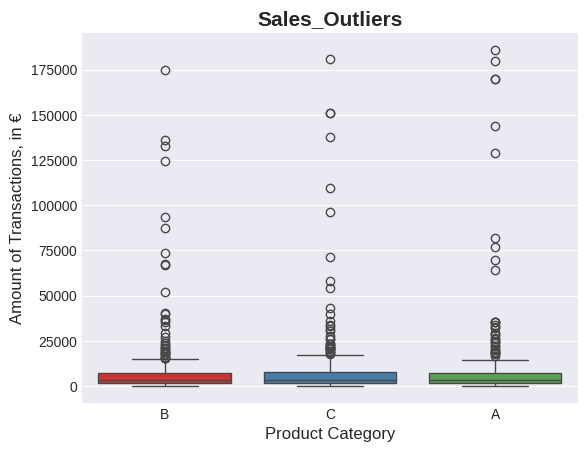

In [41]:
# ========================================
# Étape 1: Visualiser la distribution avec boxplot et histogramme
# ========================================

# TODO: Écrivez votre code ici

def box_plot(variable_x, variable_y, data, color_palette, title, title_x, title_y):
  sns.boxplot(x = variable_x, y = variable_y, data=data, palette=color_palette)
  plt.title(title, fontweight="bold", fontsize =15)
  plt.xlabel(title_x, fontsize=12)
  plt.ylabel(title_y, fontsize=12)
  plt.show()
box_plot('product', 'amount', df, "Set1", 'Sales_Outliers', 'Product Category', 'Amount of Transactions, in €')

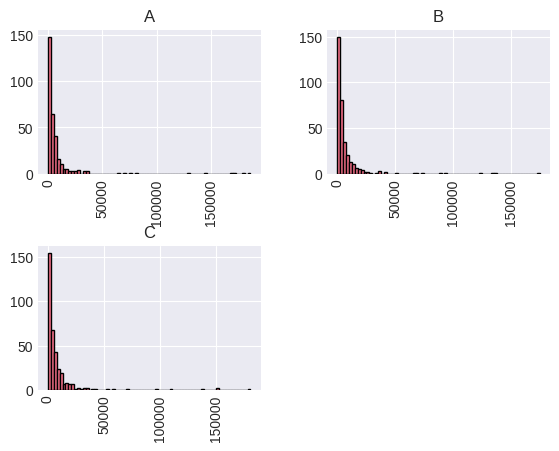

In [42]:
def histogram_plot(data, column = "variable_x", by= "variable_y"):
  data.hist(column= 'amount', by='product', bins = 70, edgecolor = 'black')
  #plt.title(title, fontweight="bold", fontsize =15)
  #plt.xlabel(title_x, fontsize=12)
  #plt.ylabel(title_y, fontsize=12)
  plt.show()
histogram_plot(df, "amount", "product")

Text(0.5, 1.0, 'Sales_Outliers')

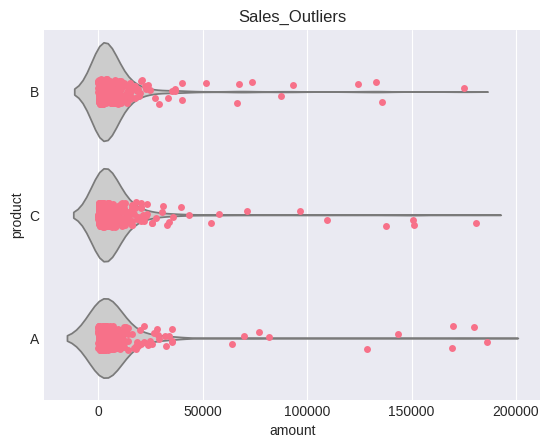

In [43]:
#Mean distribution grapgh, violin plot

ax = sns.violinplot(x =df['amount'], y =df['product'], data=df, inner=None, color=".8")

ax = sns.stripplot(x =df['amount'], y =df['product'], data=df)

ax.set_title('Sales_Outliers')

In [44]:
# ========================================
# Étape 2: Calculer les statistiques descriptives
# ========================================

# TODO: Écrivez votre code ici
display(df.describe())

# Vérification
print(f" Étape 2 complétée")

,transaction_id,amount
count,1020.00,1020.00
mean,510.50,8616.96
std,294.59,20525.04
min,1.00,79.57
25%,255.75,1441.20
50%,510.50,3152.76
75%,765.25,7221.39
max,1020.00,185913.06


 Étape 2 complétée


In [45]:
# ========================================
# Étape 3: Implémenter la détection par méthode IQR
# ========================================

# Détection par IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    iqr_outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return iqr_outliers, lower_bound, upper_bound

# Utilisation
iqr_outliers, lower, upper = detect_outliers_iqr(df, 'amount')
print(f"Nombre d'outliers: {len(iqr_outliers)}")
print(f"Limites: [{lower:.2f}, {upper:.2f}]")

Nombre d'outliers: 105
Limites: [-7229.09, 15891.68]


In [46]:
# ========================================
# Étape 4: Implémenter la détection par Z-score
# ========================================

# TODO: Écrivez votre code ici
# Calcul du Z-score
z_scores = np.abs(stats.zscore(df['amount']))
threshold = 3

# Détection des outliers
zscore_outliers = df[z_scores > threshold]
print(f"Outliers détectés: {len(zscore_outliers)}")

# Vérification
print(f" Étape 4 complétée")

Outliers détectés: 22
 Étape 4 complétée


In [47]:
# ========================================
# Étape 5: Comparer les résultats des deux méthodes
# ========================================

# TODO: Écrivez votre code ici
if  len(iqr_outliers)> len(zscore_outliers):
  print(f"IQR detected more outliners than Z_score method")
elif len(iqr_outliers) < len(zscore_outliers):
  print(f"IQR method detected fewer outliners than Z_score method")
else:
  print("No significant difference")

# Vérification
print(f" Étape 5 complétée")

IQR detected more outliners than Z_score method
 Étape 5 complétée


In [48]:
# @title
# ========================================
# Étape 6: Décider d'une stratégie: suppression ou capping
# ========================================

# TODO: Écrivez votre code ici
print(len(iqr_outliers))
print(len(zscore_outliers))

print(f"Meme si il y a plus de détection des outliers en IQR, IQR change le taille de dataset. Donc, le capping est pris comme stratégie car il garde le taille.")
# Vérification
print(f" Étape 6 complétée")

105
22
Meme si il y a plus de détection des outliers en IQR, IQR change le taille de dataset. Donc, le capping est pris comme stratégie car il garde le taille.
 Étape 6 complétée


In [49]:
# ========================================
# Étape 7: Appliquer le capping (Winsorization) aux valeurs extrêmes
# ========================================

# TODO: Écrivez votre code ici
p5 = df.amount.quantile(0.05)
p95 = df.amount.quantile(0.95)

df_clean = df.copy()
df_clean['amount'] = df_clean['amount'].clip(lower=p5, upper=p95)
print(df_clean.shape)
# Vérification
print(f" Étape 7 complétée")

(1020, 4)
 Étape 7 complétée


 Étape 8 complétée


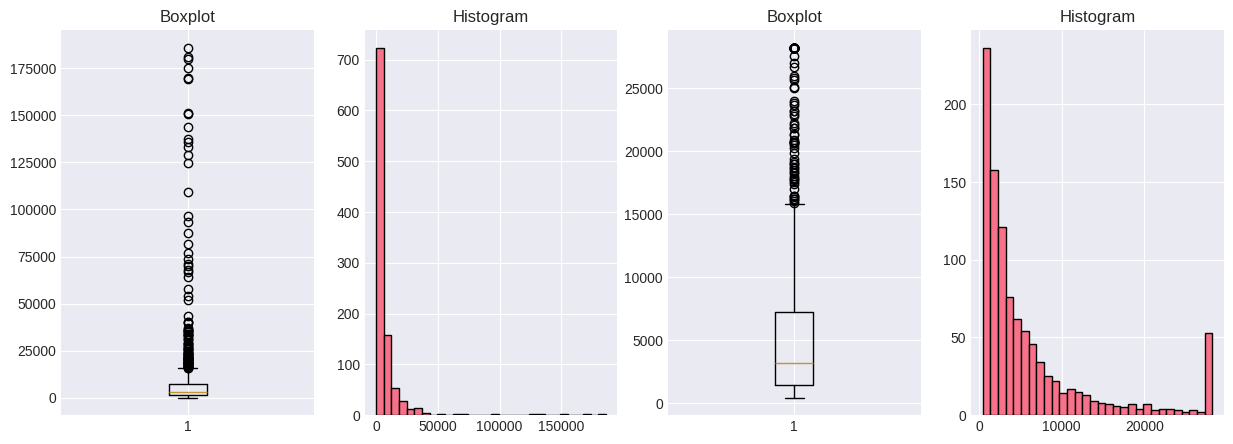

In [50]:
# ========================================
# Étape 8: Visualiser la distribution avant/après traitement
# ========================================

# TODO: Écrivez votre code ici
# Histogram 1
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

# Boxplot
axes[0].boxplot(df['amount'])
axes[0].set_title('Boxplot')

# Histogram
axes[1].hist(df['amount'], bins=30, edgecolor='black')
axes[1].set_title('Histogram')
####
axes[2].boxplot(df_clean['amount'])
axes[2].set_title('Boxplot')

# Histogram
axes[3].hist(df_clean['amount'], bins=30, edgecolor='black')
axes[3].set_title('Histogram')

# Vérification
print(f" Étape 8 complétée")

In [51]:
# ========================================
# Étape 9: Calculer l'impact sur les statistiques (moyenne, écart-type)
# ========================================

# TODO: Écrivez votre code ici
display(df.describe())
display(df_clean.describe())

# Vérification
print(f" Étape 9 complétée")

,transaction_id,amount
count,1020.00,1020.00
mean,510.50,8616.96
std,294.59,20525.04
min,1.00,79.57
25%,255.75,1441.20
50%,510.50,3152.76
75%,765.25,7221.39
max,1020.00,185913.06


,transaction_id,amount
count,1020.00,1020.00
mean,510.50,6066.40
std,294.59,7187.67
min,1.00,439.73
25%,255.75,1441.20
50%,510.50,3152.76
75%,765.25,7221.39
max,1020.00,28244.08


 Étape 9 complétée


In [52]:
# ========================================
# Étape 10: Documenter les outliers traités dans un rapport
# ========================================

# TODO: Écrivez votre code ici

outliers = [len(iqr_outliers), len(zscore_outliers)]
print(outliers)

# Vérification
print(f" Étape 10 complétée")

[105, 22]
 Étape 10 complétée


## Rapport Final

**Créez un rapport résumant toutes les transformations effectuées**


In [66]:
# Rapport de nettoyage
rapport = {
    'Dimensions_initiales': df.shape,
    'Dimensions_finales': df_clean.shape,  # À mettre à jour avec df_clean
    'Lignes_supprimées': len(df)-len(df_clean),
    'Colonnes_supprimées': df.shape[1]-df_clean.shape[1],
    'Valeurs_manquantes_traitées': 0,
    'Doublons_supprimés': 0,
    'Outliers_traités': 0,
    'Transformations_appliquées': []
}

print("=" * 80)
print(" " * 25 + " RAPPORT DE NETTOYAGE")
print("=" * 80)

for key, value in rapport.items():
    print(f"{key:.<40} {value}")

print("=" * 80)
print("\n✅ TP terminé avec succès!")

                          RAPPORT DE NETTOYAGE
Dimensions_initiales.................... (1020, 4)
Dimensions_finales...................... (1020, 4)
Lignes_supprimées....................... 0
Colonnes_supprimées..................... 0
Valeurs_manquantes_traitées............. 0
Doublons_supprimés...................... 0
Outliers_traités........................ 0
Transformations_appliquées.............. []

✅ TP terminé avec succès!
